<a href="https://colab.research.google.com/github/soulkod/DataScience/blob/main/FirstDataScienceProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
#to import the pandas library
import pandas as pd

dataset = pd.read_csv('/content/train.csv')

print('The dataset has been successfully uploaded, King!!')
#to show how the data looks like
print('Data shape:', dataset.shape)

dataset.head() #shows the first 5 records

#import libraries
import numpy as np
import pandas as pd #Data manipoulatuio
import matplotlib.pyplot as pit #ploting data

from sklearn.model_selection import train_test_split #library for spliting data
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import  OneHotEncoder, StandardScaler #catogotrial variables to numerical

from sklearn.linear_model import LogisticRegression #for achine learning
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)#classifcation report
display(dataset.head())

print(f'Rows: {dataset.shape[0]}')
print(f'Columns: {dataset.shape[0]}')

#To display coluns names
print(dataset.columns.tolist())

#to display the non-null values
dataset.info()
#to display the statistical values
dataset.describe(include='all').T


The dataset has been successfully uploaded, King!!
Data shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Rows: 891
Columns: 891
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


Columns containing missing values
          Missing Values  Missing Percentage
Cabin                687               77.10
Age                  177               19.87
Embarked               2                0.22


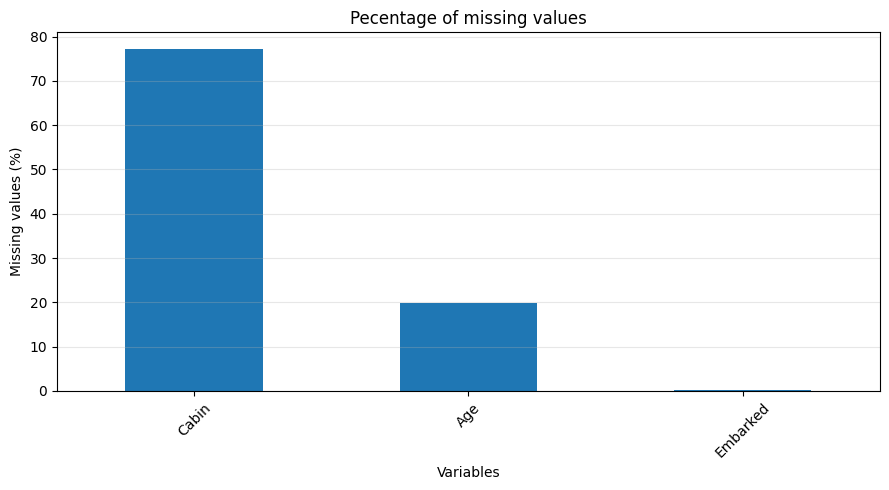

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64
Independent variable shape: (891, 7)
Dependent Variables shape: (891,)

Independent varibales:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S



Dependent variables:


,Survived
0,0
1,1
2,1
3,1
4,0


In [18]:
dataset.nunique().sort_values()
#dealing with missing valuess
missing_values = dataset.isnull().sum()

missing_table = pd.DataFrame({
    "Missing Values":missing_values,
    "Missing Percentage":(
        missing_values / len(dataset) * 100
    ).round(2)
    })

#to get only the records that have missing values
missing_table = missing_table[
    missing_table["Missing Values"] > 0
].sort_values(by="Missing Values",
              ascending=False)
print("Columns containing missing values")
print(missing_table)

import matplotlib.pyplot as plt


if not missing_table.empty:
  ax = missing_table["Missing Percentage"].plot(kind="bar",figsize=(9,5))

  ax.set_title("Pecentage of missing values")
  ax.set_xlabel("Variables")
  ax.set_ylabel("Missing values (%)")
  ax.grid(axis="y", alpha=0.3)

  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

else:
  print("The dataset contains no missing values.")


selected_features =[
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

print(dataset[selected_features].isnull().sum())

#independent variables the cabin column was removed
x = dataset[
    [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
  ]
].copy()

#dependent varibales
y = dataset["Survived"].copy()

print("Independent variable shape:",x.shape)
print("Dependent Variables shape:",y.shape)

#printing the first 5 rows in each
print("\nIndependent varibales:")
display(x.head())

print("\nDependent variables:")
display(y.head())

,Survived,Frequency,Percentage
0,No,549,61.62
1,Yes,342,38.38


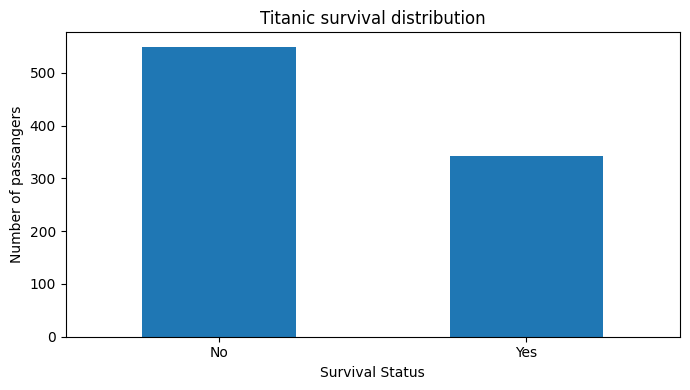

In [19]:
target_counts = y.value_counts().sort_index()

#creating a data frame which is a table that contains only the survivors]

target_table= pd.DataFrame({
    "Survived":["No","Yes"],
    "Frequency":[
        target_counts.get(0,0),
        target_counts.get(1,0)
    ]
})

target_table["Percentage"] = (
    target_table["Frequency"] / len(y) * 100
).round(2)

display(target_table)

#plotting a bar graph

ax = target_table.plot(
    kind= "bar",
    x= "Survived",
    y="Frequency",
    legend=False,
    figsize=(7,4)
)

ax.set_title("Titanic survival distribution")
ax.set_ylabel("Number of passangers")
ax.set_xlabel("Survival Status")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [20]:
#Identify numerical and categorial varibales

numerical_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

categorcal_features =[
    "Sex",
    "Embarked"
]

print("Numerical variables:")
print(numerical_features)
print("\nCategorical features")
print(categorcal_features)

for column in categorcal_features:
  print(f"\nCategories in {column}")
  print(x[column].value_counts(dropna=False))

Numerical variables:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical features
['Sex', 'Embarked']

Categories in Sex
Sex
male      577
female    314
Name: count, dtype: int64

Categories in Embarked
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64


In [21]:
from sklearn.model_selection import train_test_split

x_train, x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("The x train set:",x_train.shape)
print("The x test set:",x_test.shape)
print("The y train set:",y_train.shape)
print("The y test set:",y_test.shape)

#checking the distribution of data
print("Training-set surviuval distribution")
print(y_train.value_counts(normalize=True).sort_index().round(3))

print("Test-set surviuval distribution")
print(y_test.value_counts(normalize=True).sort_index().round(3))

The x train set: (712, 7)
The x test set: (179, 7)
The y train set: (712,)
The y test set: (179,)
Training-set surviuval distribution
Survived
0    0.617
1    0.383
Name: proportion, dtype: float64
Test-set surviuval distribution
Survived
0    0.615
1    0.385
Name: proportion, dtype: float64


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import  OneHotEncoder, StandardScaler

numerical_transformer = Pipeline(
    steps=[
        #to replace the missing numerical values with the medidan
        ("inputer",SimpleImputer(strategy="median")),

        #to standardise numerical values
        ("scaler",StandardScaler())
    ]
)

categorcal_transformer = Pipeline(
    steps=[
        #replace the missing categpries wioth the frequent value
        ("inputer",SimpleImputer(strategy="most_frequent")),

        #Convert categories into binary dummy variables
        ("encoder",OneHotEncoder(
            handle_unknown="ignore",
            drop="first",
            sparse_output=False
        ))
    ]
)

print(categorcal_transformer)



from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_features
        ),
        (
            "categorical",
            categorcal_transformer,
            categorcal_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

display(preprocessor)


#Fit all preprocessing operations using training data only.
x_train_processed = preprocessor.fit_transform(x_train)

# Apply the learned transformation to the data.
x_test_processed = preprocessor.fit_transform(x_test)

print("Processerd training set shape:",x_train_processed.shape)
print("Processerd test set shape:",x_test_processed.shape)

# obtain the names of the newly created variables
processed_feature_names = preprocessor.get_feature_names_out()

x_train_processed = pd.DataFrame(
    x_train_processed,
    columns=processed_feature_names,
    index=x_train.index
)

x_test_processed = pd.DataFrame(
    x_test_processed,
    columns=processed_feature_names,
    index=x_test.index
)

print("Processed training data:")
display(x_train_processed.head())

print("Processed test data:")
display(x_test_processed.head())

Pipeline(steps=[('inputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(drop='first', handle_unknown='ignore',
                               sparse_output=False))])


ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('inputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']),
                                ('categorical',
                                 Pipeline(steps=[('inputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Sex', 'Embarked'])],
                  verbose_feature_names_out=False)

Processerd training set shape: (712, 8)
Processerd test set shape: (179, 8)
Processed training data:


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
692,0.829568,-0.081135,-0.465084,-0.466183,0.513812,1.0,0.0,1.0
481,-0.370945,-0.081135,-0.465084,-0.466183,-0.662563,1.0,0.0,1.0
527,-1.571457,-0.081135,-0.465084,-0.466183,3.955399,1.0,0.0,1.0
855,0.829568,-0.887827,-0.465084,0.727782,-0.467874,0.0,0.0,1.0
801,-0.370945,0.110934,0.478335,0.727782,-0.115977,0.0,0.0,1.0


Processed test data:


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
565,0.818879,-0.365832,1.087142,-0.522951,-0.172088,1.0,0.0,1.0
160,0.818879,1.175419,-0.514491,0.986859,-0.316645,1.0,0.0,1.0
553,0.818879,-0.519957,-0.514491,-0.522951,-0.476017,1.0,0.0,0.0
860,0.818879,0.944231,1.087142,-0.522951,-0.352411,1.0,0.0,1.0
241,0.818879,-0.134644,0.286326,-0.522951,-0.327420,0.0,1.0,0.0


In [23]:
print(
    "Missing values in the training data:",
    x_train_processed.isnull().sum().sum()
)

print(
    "Missing values in prrocessed test data:",
    x_test_processed.isnull().sum().sum()
)

print("Summary of scaled training vbariables:")
display(
    x_train_processed[numerical_features]
    .describe()
    .round(3)
)

Missing values in the training data: 0
Missing values in prrocessed test data: 0
Summary of scaled training vbariables:


,Pclass,Age,SibSp,Parch,Fare
count,712.000,712.000,712.000,712.000,712.000
mean,-0.000,0.000,-0.000,-0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001
min,-1.571,-2.238,-0.465,-0.466,-0.663
25%,-0.371,-0.581,-0.465,-0.466,-0.498
50%,0.830,-0.081,-0.465,-0.466,-0.362
75%,0.830,0.495,0.478,-0.466,-0.017
max,0.830,3.875,7.082,6.698,10.005


In [24]:
# using the linear regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(x_train_processed, y_train)

# pedict the test-set classes
y_pred = model.predict(x_test_processed)

print("Model trained successfully")

Model trained successfully


In [25]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)#classifcation report

accuracy = accuracy_score(y_test, y_pred)

print(f"Test accuracy: {accuracy:.4F}")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Did not survive","Survived"]
    )
)

Test accuracy: 0.7989
                 precision    recall  f1-score   support

Did not survive       0.81      0.88      0.84       110
       Survived       0.78      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.79      0.77      0.78       179
   weighted avg       0.80      0.80      0.80       179



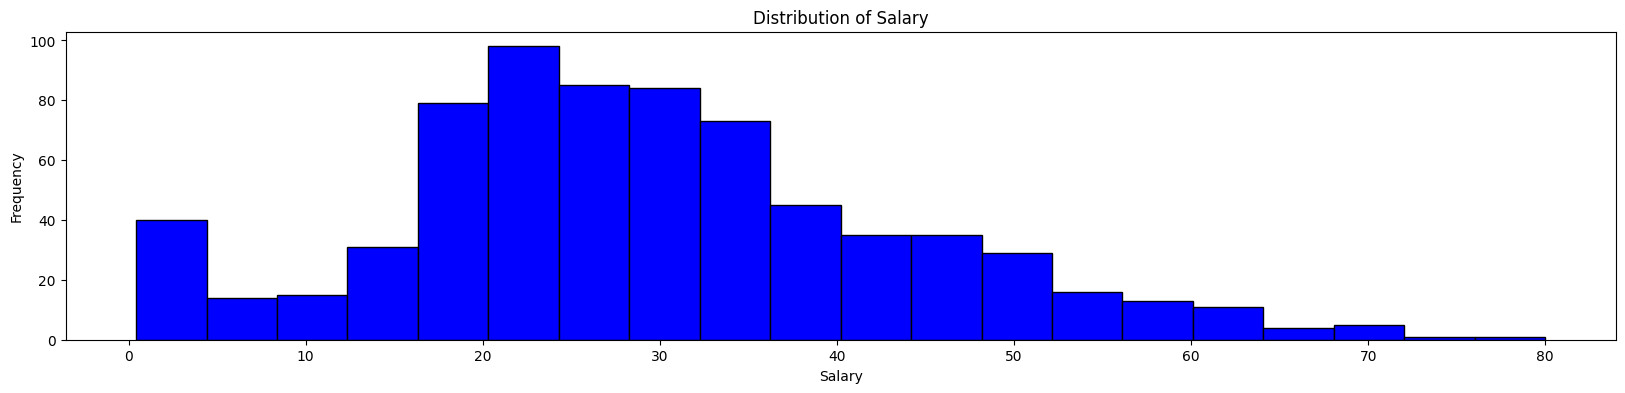

In [26]:
import matplotlib.pyplot as pit

plt.figure(figsize=(20, 4))
plt.hist(dataset['Age'], bins=20, color='blue', edgecolor='black')
plt.title("Distribution of Salary")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

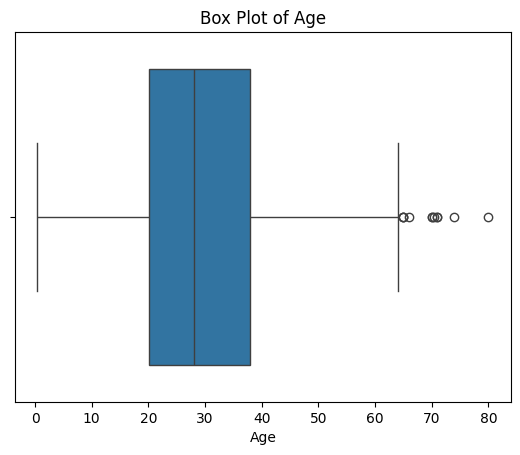

In [27]:
import seaborn as sns

sns.boxplot(x=dataset['Age'])
plt.title("Box Plot of Age")
plt.show()

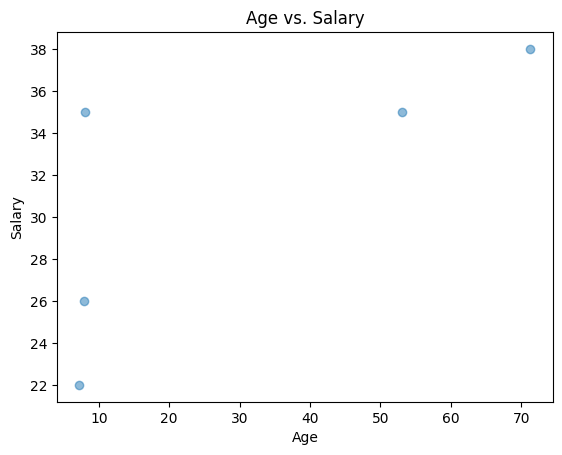

In [28]:
plt.scatter(data=dataset.head(),y='Age', x='Fare', alpha=0.5)
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs. Salary")
plt.show()

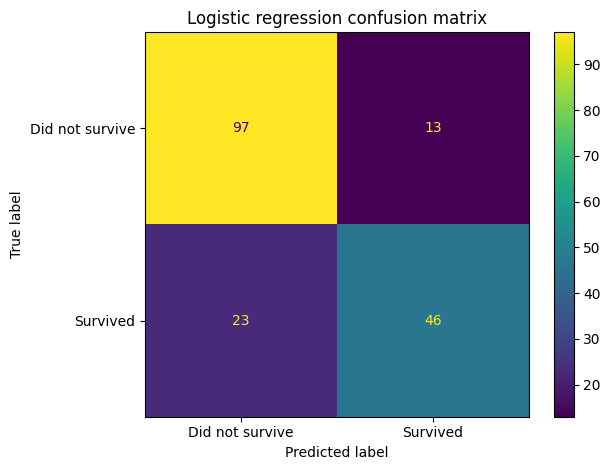

In [29]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Did not survive","Survived"],
    values_format="d"
)

plt.title("Logistic regression confusion matrix")
plt.tight_layout()
plt.show()


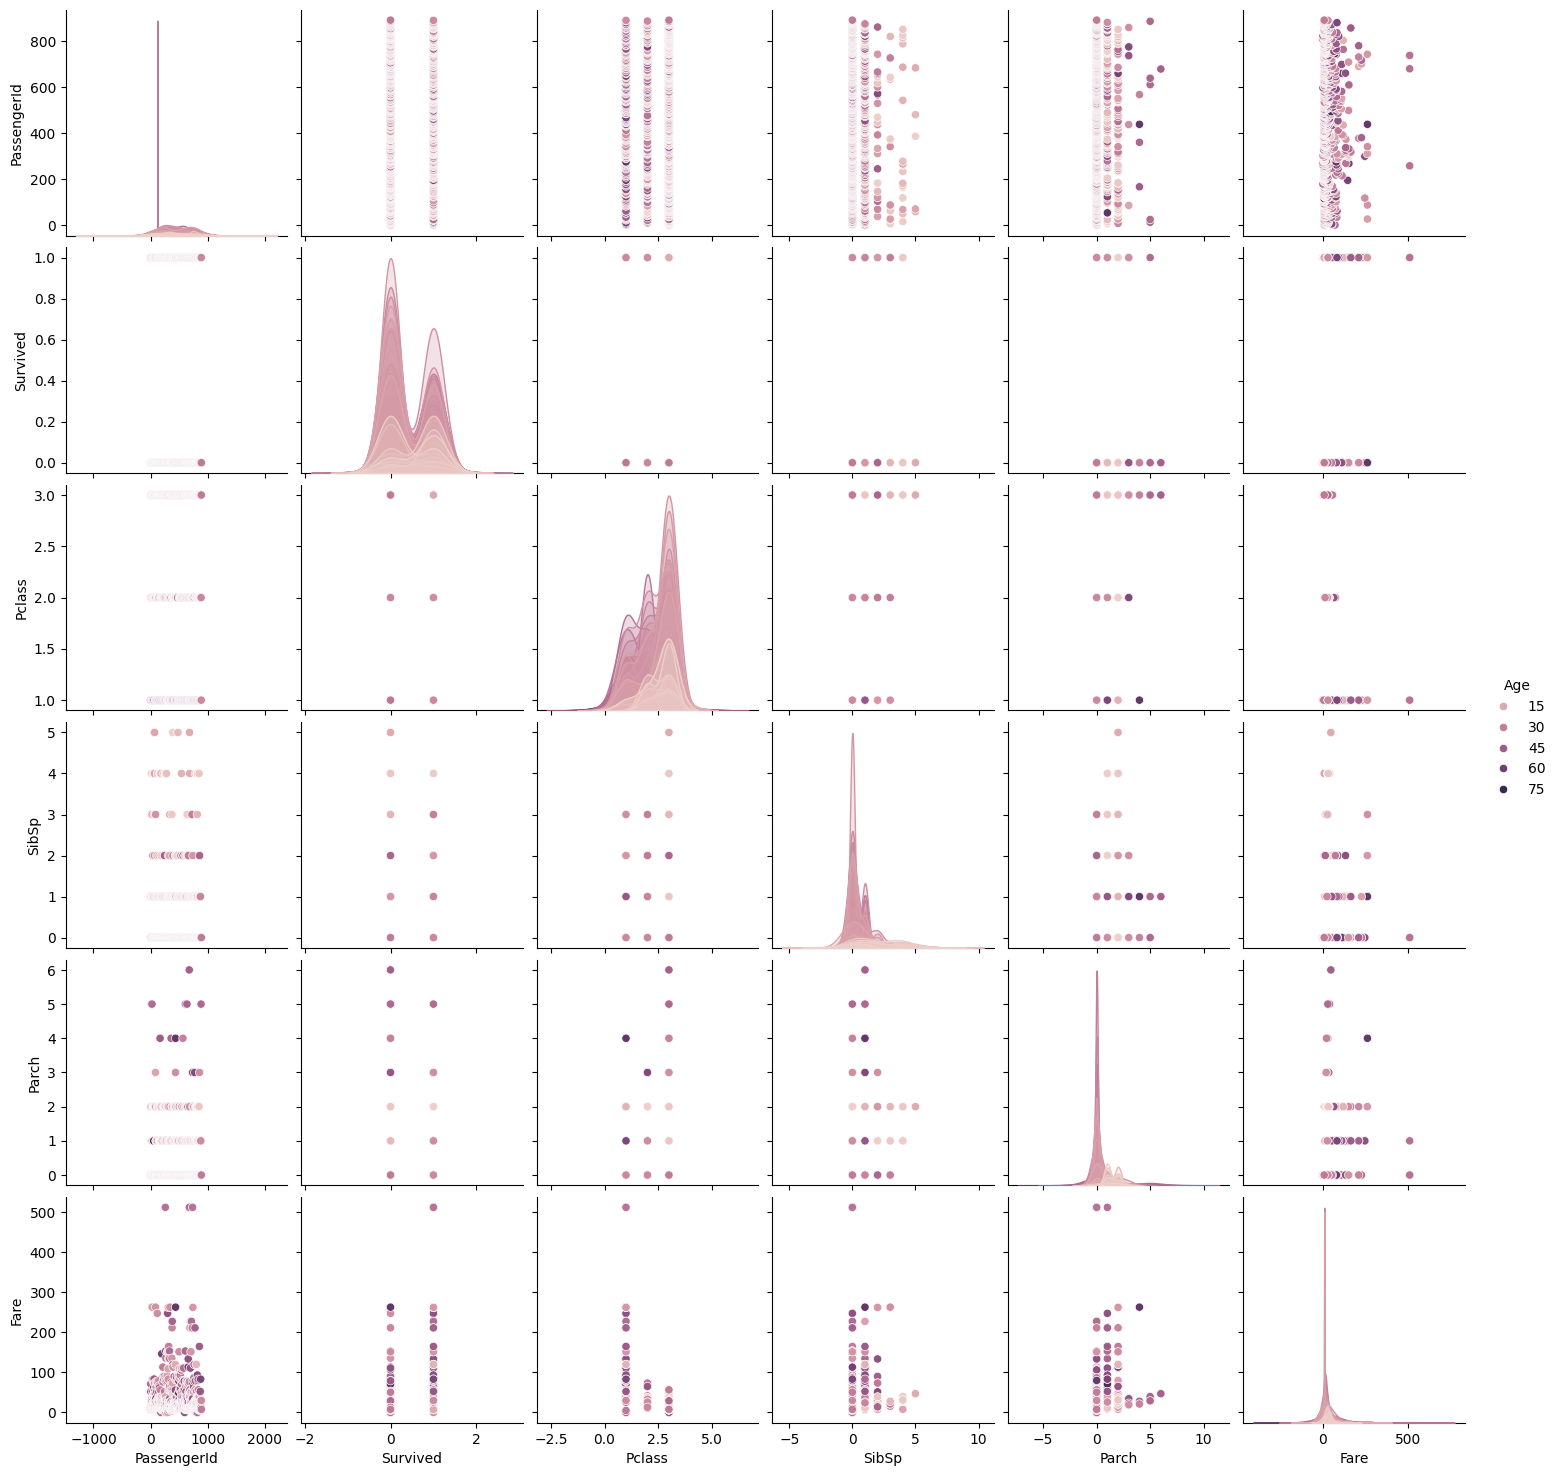

In [30]:
sns.pairplot(dataset, hue='Age')
plt.show()